# EDA — Musical Instruments Dataset

**Dataset**: `Musical_Instruments_filtered.parquet`  
**Columns**: `text`, `rating`, `subcategory`, `helpful_vote`, `verified_purchase`  

**Goals**:
1. Understand overall data quality — nulls, anomalies, distributions
2. Analyse `verified_purchase` and its effect on review quality
3. Examine rating distribution and class imbalance
4. Profile subcategories to support selection for downstream LDA & classification

In [1]:
import warnings
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
pd.set_option('display.float_format', lambda x: f'{x:.2f}')  
pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_PATH   = '../Musical_Instruments_joined.parquet'
RATING_COLORS = ['#d73027', '#fc8d59', '#fee090', '#91cf60', '#1a9850']  # 1★ → 5★

df = pq.read_table(DATA_PATH,
                   columns=['rating', 'subcategory', 'helpful_vote', 'verified_purchase'],
                   memory_map=False).to_pandas()

print(f'Total rows: {len(df):,}')
print(f'Columns loaded: {df.columns.tolist()}')
print(f'\nData types:')
print(df.dtypes)

Total rows: 3,017,439
Columns loaded: ['rating', 'subcategory', 'helpful_vote', 'verified_purchase']

Data types:
rating                int64
subcategory          object
helpful_vote          int64
verified_purchase      bool
dtype: object


---
## 1. Data Quality Check

In [2]:
# ── Null counts ──────────────────────────────────────────────────────────────
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)

print('Null values per column:')
for col in df.columns:
    print(f'  {col:<22} {null_counts[col]:>8,}  ({null_pct[col]:.2f}%)')

# ── Text column: empty / null check (load separately) ────────────────────────
text_series = pq.read_table(DATA_PATH, columns=['text'], memory_map=False).to_pandas()['text']
text_null   = text_series.isnull().sum()
text_empty  = (text_series.fillna('').str.strip() == '').sum()
print(f'  {"text (null)":<22} {text_null:>8,}  ({text_null/len(df)*100:.2f}%)')
print(f'  {"text (empty string)":<22} {text_empty:>8,}  ({text_empty/len(df)*100:.2f}%)')

# ── Helpful vote anomaly ──────────────────────────────────────────────────────
n_neg_votes = (df['helpful_vote'] < 0).sum()
print(f'\n  helpful_vote < 0   : {n_neg_votes:,} rows — likely a data artifact, should be set to 0')
print(f'   helpful_vote range  : {df["helpful_vote"].min()} – {df["helpful_vote"].max():,}')

# ── Subcategory nulls ─────────────────────────────────────────────────────────
n_null_cat = df['subcategory'].isnull().sum()
print(f'\n  subcategory null    : {n_null_cat:,} rows ({n_null_cat/len(df)*100:.1f}%)')
print(   '   These rows cannot be assigned to any category — excluded from category-level analysis.')

Null values per column:
  rating                        0  (0.00%)
  subcategory             101,301  (3.36%)
  helpful_vote                  0  (0.00%)
  verified_purchase             0  (0.00%)
  text (null)                   0  (0.00%)
  text (empty string)       2,830  (0.09%)

  helpful_vote < 0   : 2 rows — likely a data artifact, should be set to 0
   helpful_vote range  : -1 – 4,650

  subcategory null    : 101,301 rows (3.4%)
   These rows cannot be assigned to any category — excluded from category-level analysis.


In [3]:
# ── Clean up for downstream analysis ─────────────────────────────────────────
df['helpful_vote'] = df['helpful_vote'].clip(lower=0)   
df['text'] = text_series                                  # attach text column
del text_series

df_clean = df.dropna(subset=['subcategory', 'text']).copy()
df_clean = df_clean[df_clean['text'].str.strip() != ''].reset_index(drop=True)

print(f'After cleaning (drop null subcategory + empty text):')
print(f'  Rows remaining : {len(df_clean):,}  (removed {len(df)-len(df_clean):,})')

After cleaning (drop null subcategory + empty text):
  Rows remaining : 2,913,372  (removed 104,067)


---
## 2. Verified Purchase Analysis

In [4]:
vp_counts = df['verified_purchase'].value_counts()
vp_pct    = (vp_counts / len(df) * 100).round(1)

print('Verified purchase breakdown:')
print(f'  Verified     : {vp_counts.get(True,0):>8,}  ({vp_pct.get(True,0):.1f}%)')
print(f'  Not verified : {vp_counts.get(False,0):>8,}  ({vp_pct.get(False,0):.1f}%)')

# Does verification status affect rating behaviour?
rating_by_vp = df.groupby('verified_purchase')['rating'].agg(['mean','median', 
               lambda x: (x==5).mean()*100, lambda x: (x<=2).mean()*100])
rating_by_vp.columns = ['mean_rating','median_rating','pct_5star','pct_neg']
rating_by_vp.index = ['Not verified', 'Verified']
print('\nRating behaviour by verification status:')
print(rating_by_vp.round(2).to_string())

Verified purchase breakdown:
  Verified     : 2,780,515  (92.1%)
  Not verified :  236,924  (7.9%)

Rating behaviour by verification status:
              mean_rating  median_rating  pct_5star  pct_neg
Not verified         4.09           5.00      60.04    16.26
Verified             4.27           5.00      67.68    12.85


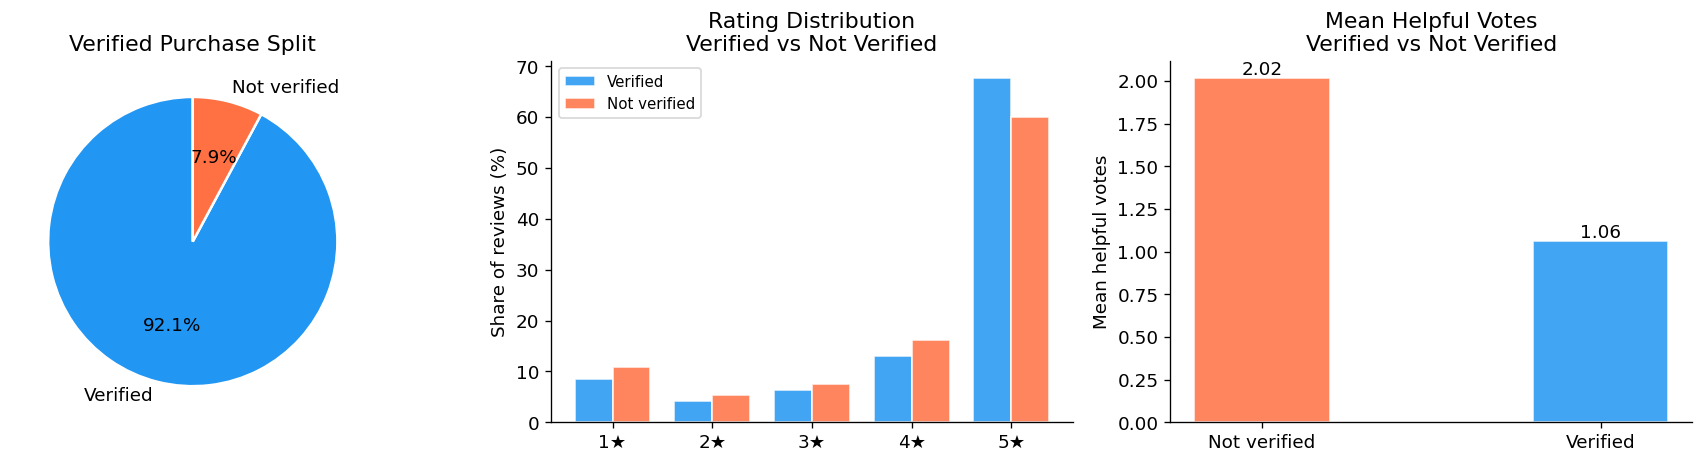

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Verified purchase pie
axes[0].pie([vp_counts.get(True,0), vp_counts.get(False,0)],
            labels=['Verified', 'Not verified'],
            colors=['#2196F3', '#FF7043'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Verified Purchase Split')

# Rating distribution — verified vs not
x = np.arange(1, 6)
w = 0.38
for offset, vp, label, color in [(-w/2, True, 'Verified', '#2196F3'),
                                   ( w/2, False,'Not verified','#FF7043')]:
    subset = df[df['verified_purchase'] == vp]['rating'].value_counts().sort_index()
    pct    = subset / subset.sum() * 100
    axes[1].bar(x + offset, pct.reindex(range(1,6), fill_value=0),
                width=w, label=label, color=color, alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{i}★' for i in range(1,6)])
axes[1].set_ylabel('Share of reviews (%)')
axes[1].set_title('Rating Distribution\nVerified vs Not Verified')
axes[1].legend(fontsize=9)

# Helpful vote mean — verified vs not
hv_by_vp = df.groupby('verified_purchase')['helpful_vote'].mean()
axes[2].bar(['Not verified', 'Verified'],
            [hv_by_vp.get(False, 0), hv_by_vp.get(True, 0)],
            color=['#FF7043', '#2196F3'], alpha=0.85, edgecolor='white', width=0.4)
axes[2].set_ylabel('Mean helpful votes')
axes[2].set_title('Mean Helpful Votes\nVerified vs Not Verified')
for i, val in enumerate([hv_by_vp.get(False,0), hv_by_vp.get(True,0)]):
    axes[2].text(i, val + 0.02, f'{val:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('fig_verified_purchase.png', bbox_inches='tight')
plt.show()

---
## 3. Rating Distribution

In [6]:
rating_counts = df['rating'].value_counts().sort_index()
rating_pct    = (rating_counts / len(df) * 100).round(1)

print('Overall rating distribution:')
for star, cnt in rating_counts.items():
    bar = '█' * int(rating_pct[star] / 2)
    print(f'  {star}★   {cnt:>8,}  ({rating_pct[star]:>5.1f}%)   {bar}')

pos = (df['rating'] >= 4).sum()
neg = (df['rating'] <= 2).sum()
neu = (df['rating'] == 3).sum()
print(f'\nPositive (4-5★) : {pos:,} ({pos/len(df)*100:.1f}%)')
print(f'Neutral  (3★)   : {neu:,} ({neu/len(df)*100:.1f}%)')
print(f'Negative (1-2★) : {neg:,} ({neg/len(df)*100:.1f}%)')
print(f'\nPos/Neg ratio   : {pos/neg:.1f}x  ← significant class imbalance for classification tasks')

Overall rating distribution:
  1★    264,352  (  8.8%)   ████
  2★    131,441  (  4.4%)   ██
  3★    197,131  (  6.5%)   ███
  4★    400,387  ( 13.3%)   ██████
  5★   2,024,128  ( 67.1%)   █████████████████████████████████

Positive (4-5★) : 2,424,515 (80.4%)
Neutral  (3★)   : 197,131 (6.5%)
Negative (1-2★) : 395,793 (13.1%)

Pos/Neg ratio   : 6.1x  ← significant class imbalance for classification tasks


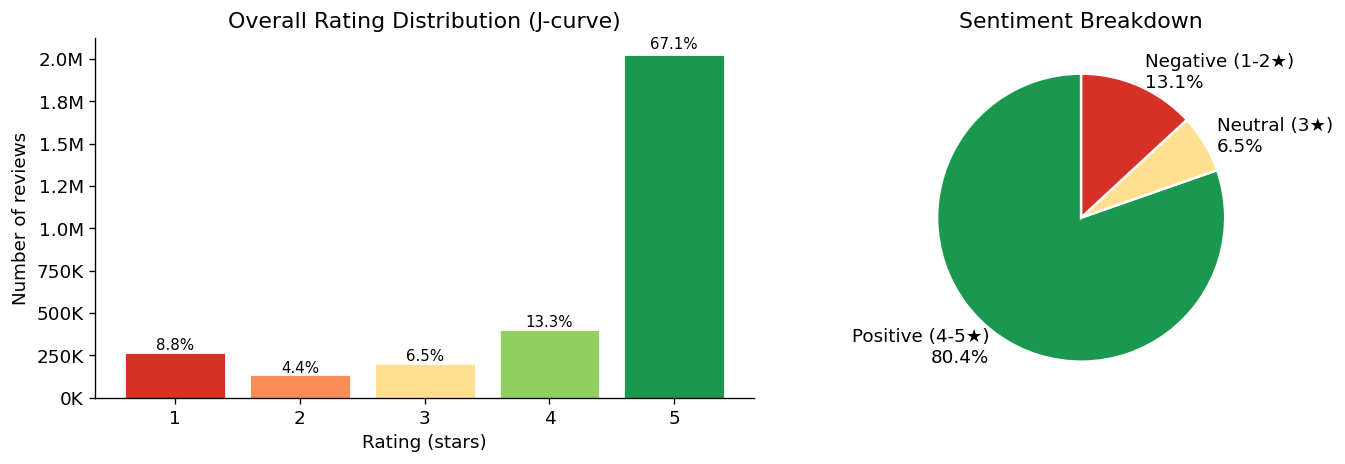

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(rating_counts.index, rating_counts.values,
                   color=RATING_COLORS, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Rating (stars)')
axes[0].set_ylabel('Number of reviews')
axes[0].set_title('Overall Rating Distribution (J-curve)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
for bar, pct in zip(bars, rating_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'{pct}%', ha='center', va='bottom', fontsize=9)

# Sentiment breakdown
axes[1].pie([pos, neu, neg],
            labels=[f'Positive (4-5★)\n{pos/len(df)*100:.1f}%',
                    f'Neutral (3★)\n{neu/len(df)*100:.1f}%',
                    f'Negative (1-2★)\n{neg/len(df)*100:.1f}%'],
            colors=['#1a9850', '#fee090', '#d73027'],
            startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Sentiment Breakdown')

plt.tight_layout()
plt.savefig('fig_rating_distribution.png', bbox_inches='tight')
plt.show()

---
## 4. Subcategory Distribution

In [8]:
# Only subcategories with >= 5,000 reviews (exclude promo/store labels)
cat_stats = df_clean.groupby('subcategory').agg(
    n_reviews        = ('rating', 'count'),
    mean_rating      = ('rating', 'mean'),
    pct_5star        = ('rating', lambda x: (x == 5).mean() * 100),
    pct_neg          = ('rating', lambda x: (x <= 2).mean() * 100),
    pct_verified     = ('verified_purchase', 'mean'),
).round(2)
cat_stats = cat_stats[cat_stats['n_reviews'] >= 5000].sort_values('n_reviews', ascending=False)
cat_stats['pos_neg_ratio'] = (
    df_clean[df_clean['rating'] >= 4].groupby('subcategory').size() /
    df_clean[df_clean['rating'] <= 2].groupby('subcategory').size().replace(0, 1)
).reindex(cat_stats.index).round(1)

print(f'Subcategories with >= 5,000 reviews: {len(cat_stats)}')
print()
print(cat_stats.to_string())

Subcategories with >= 5,000 reviews: 14

                                n_reviews  mean_rating  pct_5star  pct_neg  pct_verified  pos_neg_ratio
subcategory                                                                                            
Instrument Accessories            1147122         4.36      70.63    10.84          0.94           7.70
Microphones & Accessories          418912         4.13      62.83    15.93          0.92           4.80
Live Sound & Stage                 311863         4.24      67.56    13.91          0.93           5.80
Studio Recording Equipment         186683         4.08      60.91    16.78          0.88           4.50
Drums & Percussion                 144453         4.34      70.01    11.11          0.92           7.40
Guitars                            133892         4.19      63.41    13.81          0.87           5.70
Electronic Music, DJ & Karaoke     128912         4.16      64.46    15.43          0.91           5.00
Amplifiers & Effects   

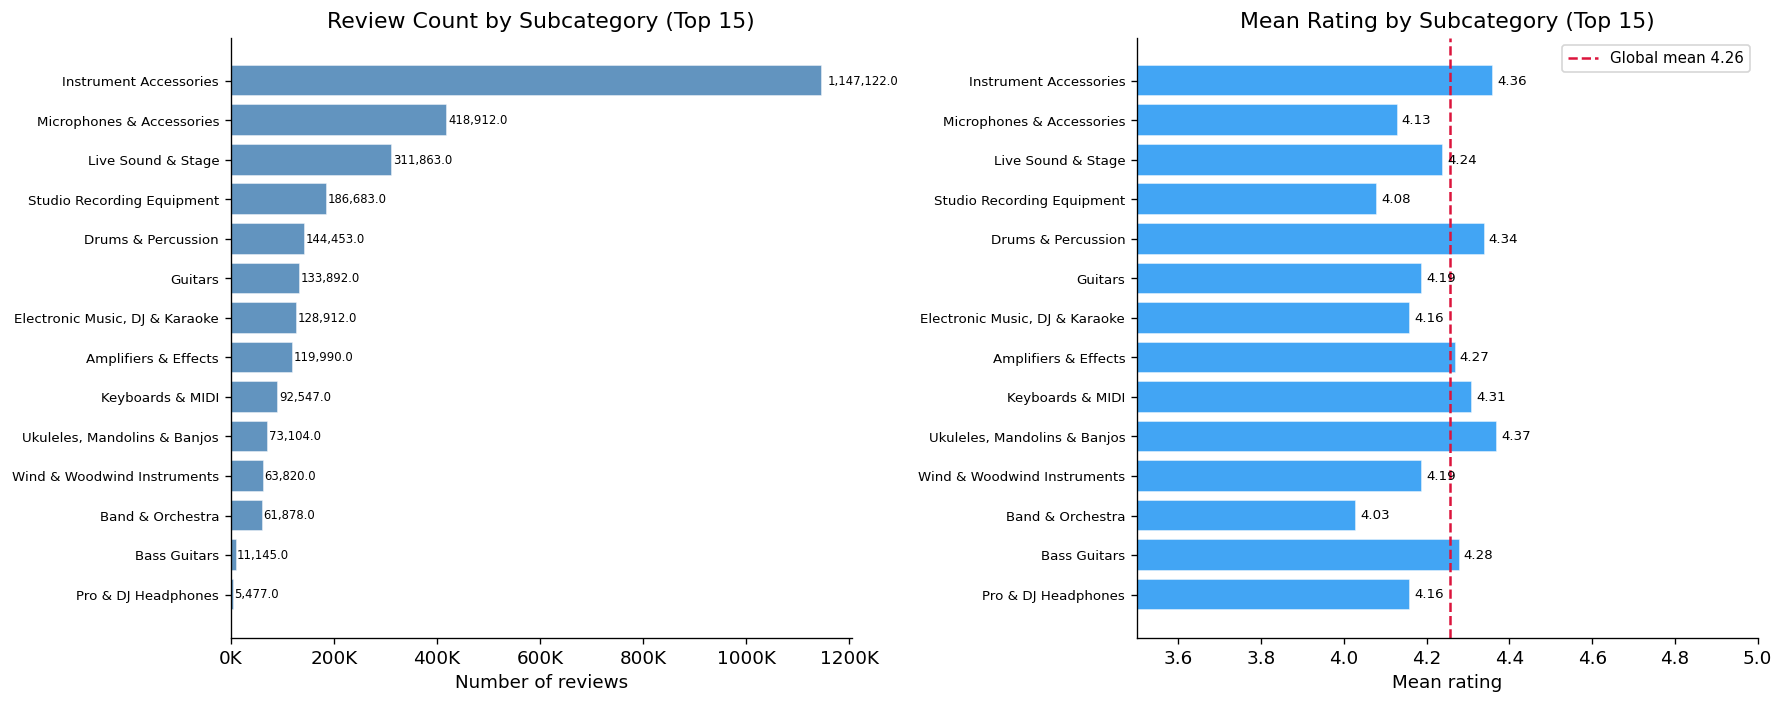

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top15 = cat_stats.head(15)

# Review count
axes[0].barh(range(len(top15)), top15['n_reviews'],
             color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(top15.index, fontsize=8)
axes[0].set_xlabel('Number of reviews')
axes[0].set_title('Review Count by Subcategory (Top 15)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].invert_yaxis()
for i, (_, row) in enumerate(top15.iterrows()):
    axes[0].text(row['n_reviews'] * 1.01, i, f'{row["n_reviews"]:,}', va='center', fontsize=7)

# Mean rating
bar_colors = ['#2196F3' if r >= 4.0 else '#FF7043' for r in top15['mean_rating']]
axes[1].barh(range(len(top15)), top15['mean_rating'],
             color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].axvline(df['rating'].mean(), color='crimson', linestyle='--',
                linewidth=1.5, label=f'Global mean {df["rating"].mean():.2f}')
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels(top15.index, fontsize=8)
axes[1].set_xlabel('Mean rating')
axes[1].set_title('Mean Rating by Subcategory (Top 15)')
axes[1].set_xlim(3.5, 5.0)
axes[1].legend(fontsize=9)
axes[1].invert_yaxis()
for i, (_, row) in enumerate(top15.iterrows()):
    axes[1].text(row['mean_rating'] + 0.01, i, f'{row["mean_rating"]:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_subcategory_distribution.png', bbox_inches='tight')
plt.show()

---
## 5. Helpful Vote Distribution

In [10]:
hv = df['helpful_vote']  

print('Helpful vote statistics:')
print(hv.describe(percentiles=[.5, .75, .9, .95, .99]).to_string())
print(f'\nVotes == 0  : {(hv==0).sum():>8,}  ({(hv==0).mean()*100:.1f}%)')
print(f'Votes >= 1  : {(hv>=1).sum():>8,}  ({(hv>=1).mean()*100:.1f}%)')
print(f'Votes >= 5  : {(hv>=5).sum():>8,}  ({(hv>=5).mean()*100:.1f}%)')
print(f'Votes >= 10 : {(hv>=10).sum():>8,}  ({(hv>=10).mean()*100:.1f}%)')

Helpful vote statistics:
count   3017439.00
mean          1.14
std          10.03
min           0.00
50%           0.00
75%           1.00
90%           2.00
95%           4.00
99%          16.00
max        4650.00

Votes == 0  : 2,173,827  (72.0%)
Votes >= 1  :  843,612  (28.0%)
Votes >= 5  :  150,077  (5.0%)
Votes >= 10 :   61,252  (2.0%)


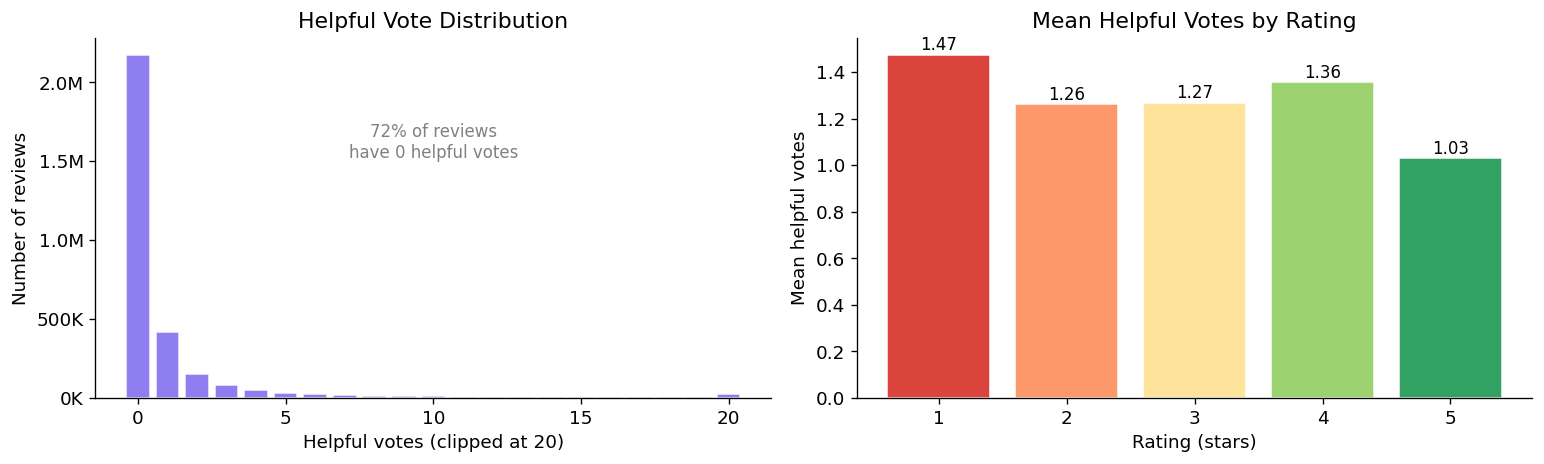

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution clipped at 20
clipped = hv.clip(upper=20)
cnt = clipped.value_counts().sort_index()
axes[0].bar(cnt.index, cnt.values, color='#7B68EE', alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Helpful votes (clipped at 20)')
axes[0].set_ylabel('Number of reviews')
axes[0].set_title('Helpful Vote Distribution')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
axes[0].text(10, cnt.iloc[0] * 0.7,
             f'{(hv==0).mean()*100:.0f}% of reviews\nhave 0 helpful votes',
             ha='center', fontsize=10, color='gray')

# Median helpful votes by rating — do negative reviews get more votes?
hv_by_rating = df.groupby('rating')['helpful_vote'].mean()
axes[1].bar(hv_by_rating.index, hv_by_rating.values,
            color=RATING_COLORS, edgecolor='white', alpha=0.9)
axes[1].set_xlabel('Rating (stars)')
axes[1].set_ylabel('Mean helpful votes')
axes[1].set_title('Mean Helpful Votes by Rating')
for star, val in hv_by_rating.items():
    axes[1].text(star, val + 0.02, f'{val:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig_helpful_vote.png', bbox_inches='tight')
plt.show()

---
## 6. Review Text Length Analysis

In [12]:
df_clean['word_count'] = df_clean['text'].str.split().str.len()

print('Word count statistics:')
print(df_clean['word_count'].describe(percentiles=[.25,.5,.75,.9,.95]).to_string())

n_short = (df_clean['word_count'] < 10).sum()
print(f'\nReviews < 10 words  : {n_short:,} ({n_short/len(df_clean)*100:.1f}%)  — too sparse for LDA')
print(f'Reviews >= 10 words : {len(df_clean)-n_short:,} ({(1-n_short/len(df_clean))*100:.1f}%)  — usable for topic modelling')

Word count statistics:
count   2913372.00
mean         44.31
std          72.25
min           1.00
25%           9.00
50%          23.00
75%          51.00
90%         103.00
95%         155.00
max        6060.00

Reviews < 10 words  : 774,267 (26.6%)  — too sparse for LDA
Reviews >= 10 words : 2,139,105 (73.4%)  — usable for topic modelling


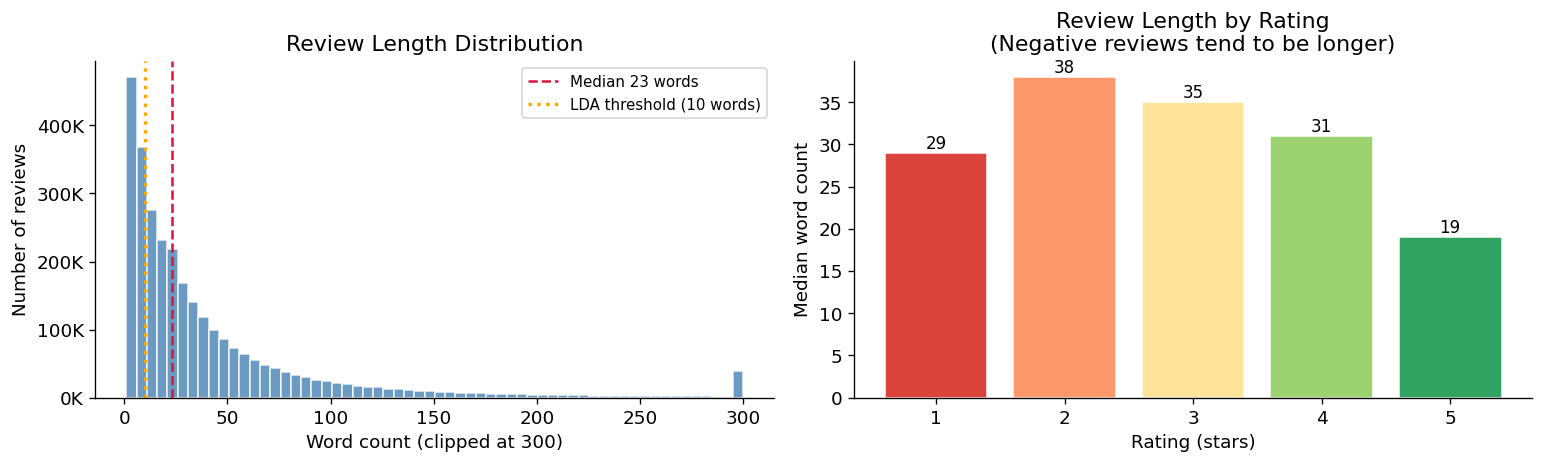

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Word count histogram
axes[0].hist(df_clean['word_count'].clip(upper=300), bins=60,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(df_clean['word_count'].median(), color='crimson', linestyle='--',
                label=f'Median {df_clean["word_count"].median():.0f} words')
axes[0].axvline(10, color='orange', linestyle=':', linewidth=2,
                label='LDA threshold (10 words)')
axes[0].set_xlabel('Word count (clipped at 300)')
axes[0].set_ylabel('Number of reviews')
axes[0].set_title('Review Length Distribution')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Median word count by rating
wc_by_rating = df_clean.groupby('rating')['word_count'].median()
axes[1].bar(wc_by_rating.index, wc_by_rating.values,
            color=RATING_COLORS, edgecolor='white', alpha=0.9)
axes[1].set_xlabel('Rating (stars)')
axes[1].set_ylabel('Median word count')
axes[1].set_title('Review Length by Rating\n(Negative reviews tend to be longer)')
for star, val in wc_by_rating.items():
    axes[1].text(star, val + 0.5, f'{val:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig_text_length.png', bbox_inches='tight')
plt.show()

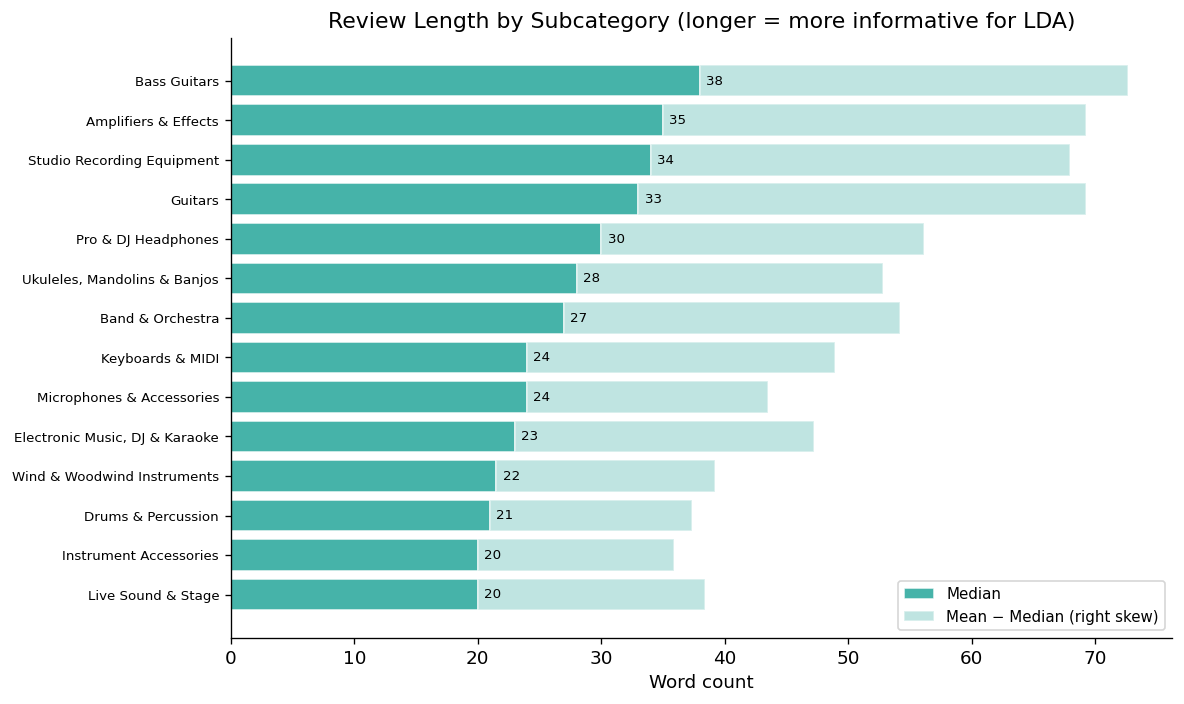

In [14]:
# Median word count by subcategory
wc_by_cat = df_clean.groupby('subcategory')['word_count'].agg(['median','mean']).round(1)
wc_by_cat = wc_by_cat.join(cat_stats[['n_reviews']]).dropna().sort_values('median', ascending=False)
wc_by_cat = wc_by_cat[wc_by_cat['n_reviews'] >= 5000]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(wc_by_cat)), wc_by_cat['median'],
        color='#26A69A', alpha=0.85, edgecolor='white', label='Median')
ax.barh(range(len(wc_by_cat)), wc_by_cat['mean'] - wc_by_cat['median'],
        left=wc_by_cat['median'],
        color='#80CBC4', alpha=0.5, edgecolor='white', label='Mean − Median (right skew)')
ax.set_yticks(range(len(wc_by_cat)))
ax.set_yticklabels(wc_by_cat.index, fontsize=8)
ax.set_xlabel('Word count')
ax.set_title('Review Length by Subcategory (longer = more informative for LDA)')
ax.invert_yaxis()
ax.legend(fontsize=9)
for i, (_, row) in enumerate(wc_by_cat.iterrows()):
    ax.text(row['median'] + 0.5, i, f'{row["median"]:.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig_wordcount_by_cat.png', bbox_inches='tight')
plt.show()

---
## 7. Sentiment Balance per Subcategory

For the strength-amplifying vs. problem-solving ad strategy comparison,  
both positive and negative reviews must be sufficiently represented.

In [15]:
bal = cat_stats.copy()
bal['n_pos'] = df_clean[df_clean['rating'] >= 4].groupby('subcategory').size().reindex(bal.index).fillna(0).astype(int)
bal['n_neu'] = df_clean[df_clean['rating'] == 3].groupby('subcategory').size().reindex(bal.index).fillna(0).astype(int)
bal['n_neg'] = df_clean[df_clean['rating'] <= 2].groupby('subcategory').size().reindex(bal.index).fillna(0).astype(int)

print('Sentiment balance per subcategory:')
print(bal[['n_reviews','n_pos','n_neu','n_neg','pos_neg_ratio','mean_rating']]
      .sort_values('pos_neg_ratio').to_string())

Sentiment balance per subcategory:
                                n_reviews   n_pos  n_neu   n_neg  pos_neg_ratio  mean_rating
subcategory                                                                                 
Band & Orchestra                    61878   46150   4498   11230           4.10         4.03
Studio Recording Equipment         186683  141041  14314   31328           4.50         4.08
Microphones & Accessories          418912  322554  29638   66720           4.80         4.13
Electronic Music, DJ & Karaoke     128912  100293   8724   19895           5.00         4.16
Wind & Woodwind Instruments         63820   49815   4522    9483           5.30         4.19
Guitars                            133892  105580   9820   18492           5.70         4.19
Live Sound & Stage                 311863  250096  18375   43392           5.80         4.24
Pro & DJ Headphones                  5477    4267    553     657           6.50         4.16
Amplifiers & Effects               

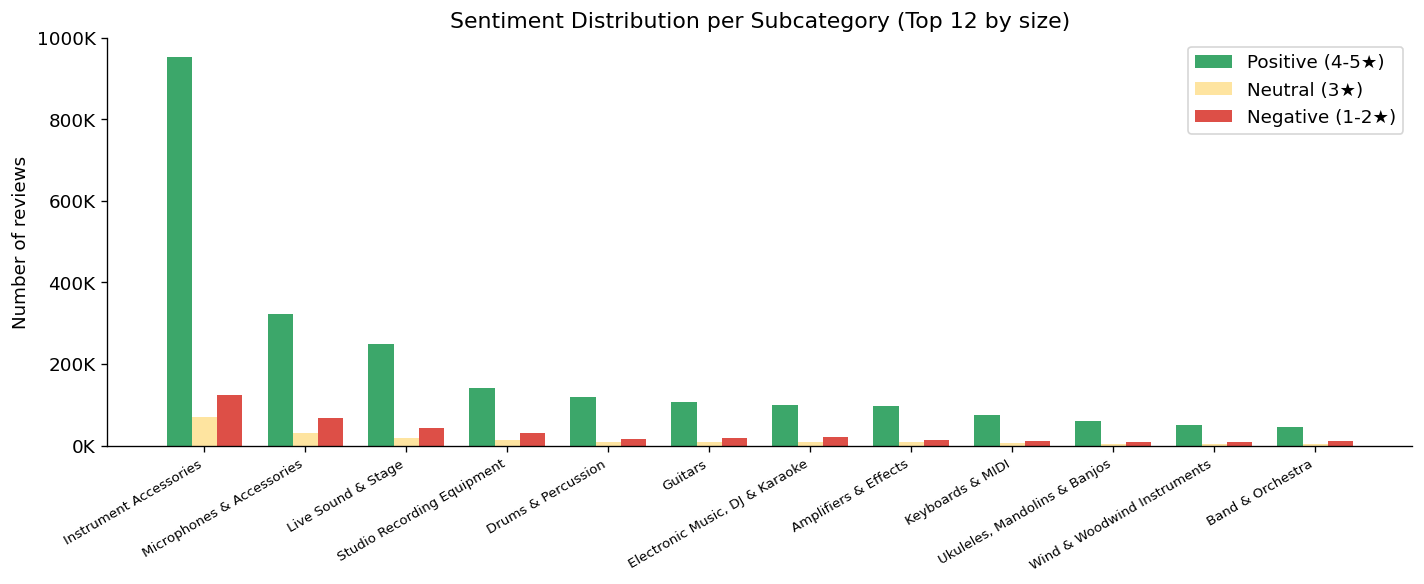

In [16]:
plot_cats = bal.sort_values('n_reviews', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_cats))
w = 0.25
ax.bar(x - w, plot_cats['n_pos'], width=w, label='Positive (4-5★)', color='#1a9850', alpha=0.85)
ax.bar(x,     plot_cats['n_neu'], width=w, label='Neutral (3★)',    color='#fee090', alpha=0.85)
ax.bar(x + w, plot_cats['n_neg'], width=w, label='Negative (1-2★)', color='#d73027', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(plot_cats.index, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Number of reviews')
ax.set_title('Sentiment Distribution per Subcategory (Top 12 by size)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('fig_sentiment_balance.png', bbox_inches='tight')
plt.show()

---
## 8. Subcategory Selection Scorecard

Quantified scoring across four criteria relevant to the research pipeline:

| Criterion | Weight | Why |
|-----------|--------|-----|
| Review count | 35% | LDA needs sufficient data to form stable, interpretable topics |
| Median review length | 35% | Longer reviews carry richer topic signal |
| Sentiment balance | 30% | Both ad strategies (strength / problem-solving) need enough positive and negative examples |

In [17]:
scorecard = bal.copy()
scorecard['median_wc'] = wc_by_cat['median'].reindex(scorecard.index)
scorecard = scorecard.dropna(subset=['median_wc'])

def norm(s, reverse=False):
    s = (s - s.min()) / (s.max() - s.min() + 1e-9) * 10
    return (10 - s) if reverse else s

scorecard['score_size']    = norm(scorecard['n_reviews'])
scorecard['score_length']  = norm(scorecard['median_wc'])
# Penalise extreme pos/neg ratios — ideal is moderate imbalance (not 20:1)
global_ratio = scorecard['pos_neg_ratio'].median()
scorecard['score_balance'] = norm((scorecard['pos_neg_ratio'] - global_ratio).abs(), reverse=True)
scorecard['total_score']   = (
    scorecard['score_size']    * 0.35 +
    scorecard['score_length']  * 0.35 +
    scorecard['score_balance'] * 0.30
).round(2)

result = scorecard[['n_reviews','median_wc','pos_neg_ratio',
                     'score_size','score_length','score_balance','total_score']]
result = result.sort_values('total_score', ascending=False)

print('Subcategory Selection Scorecard:')
print(result.to_string())

Subcategory Selection Scorecard:
                                n_reviews  median_wc  pos_neg_ratio  score_size  score_length  score_balance  total_score
subcategory                                                                                                              
Amplifiers & Effects               119990      35.00           6.70        1.00          8.33           8.82         5.91
Guitars                            133892      33.00           5.70        1.12          7.22           9.41         5.74
Bass Guitars                        11145      38.00           7.20        0.05         10.00           5.88         5.28
Pro & DJ Headphones                  5477      30.00           6.50        0.00          5.56          10.00         4.94
Instrument Accessories            1147122      20.00           7.70       10.00          0.00           2.94         4.38
Studio Recording Equipment         186683      34.00           4.50        1.59          7.78           2.35     

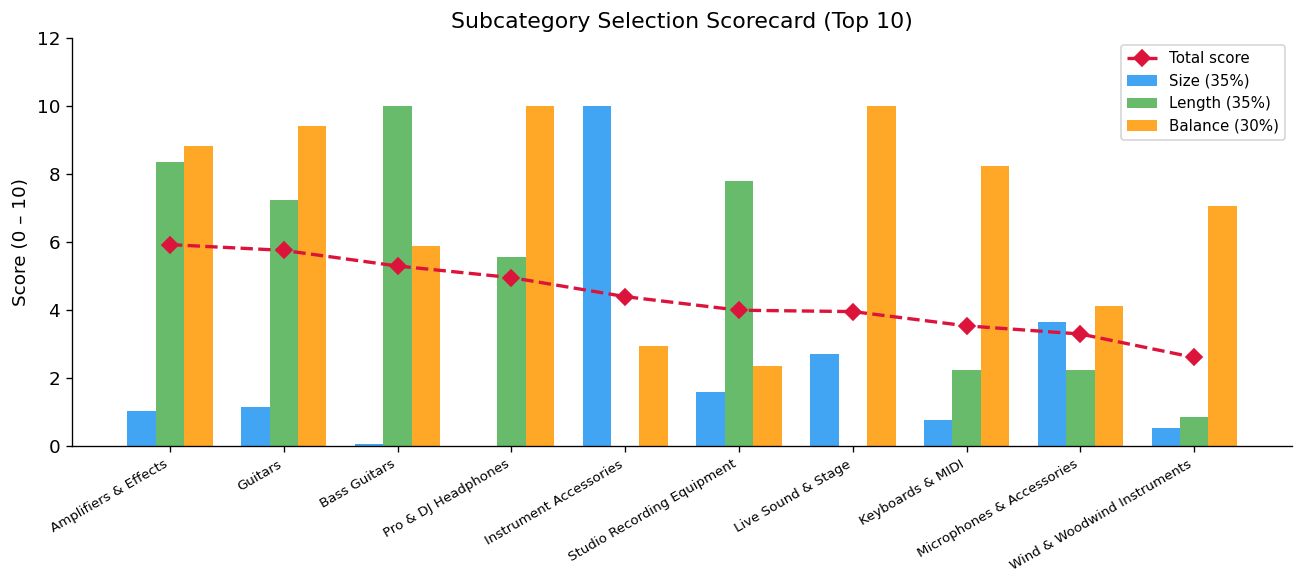

In [18]:
top_n = result.head(10)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(top_n))
w = 0.25
ax.bar(x - w, top_n['score_size'],    width=w, label='Size (35%)',    color='#2196F3', alpha=0.85)
ax.bar(x,     top_n['score_length'],  width=w, label='Length (35%)',  color='#4CAF50', alpha=0.85)
ax.bar(x + w, top_n['score_balance'], width=w, label='Balance (30%)', color='#FF9800', alpha=0.85)
ax.plot(x, top_n['total_score'], 'D--', color='crimson',
        linewidth=2, markersize=7, label='Total score', zorder=5)
ax.set_xticks(x)
ax.set_xticklabels(top_n.index, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Score (0 – 10)')
ax.set_title('Subcategory Selection Scorecard (Top 10)')
ax.legend(fontsize=9)
ax.set_ylim(0, 12)
plt.tight_layout()
plt.savefig('fig_scorecard.png', bbox_inches='tight')
plt.show()

---
## 9. Summary & Key Findings

In [19]:
print('=' * 62)
print('  Dataset Overview')
print('=' * 62)
print(f'Total rows                  : {len(df):,}')
print(f'After cleaning              : {len(df_clean):,}')
print(f'Subcategories (>= 5K)       : {len(cat_stats)}')
print(f'Verified purchase rate      : {df["verified_purchase"].mean()*100:.1f}%')
print(f'Mean rating (all)           : {df["rating"].mean():.3f}')
print(f'5-star share                : {(df["rating"]==5).mean()*100:.1f}%')
print(f'Pos/Neg ratio               : {pos/neg:.1f}x')
print(f'Subcategory null rows       : {n_null_cat:,} ({n_null_cat/len(df)*100:.1f}%)')
print(f'Negative helpful_vote rows  : {n_neg_votes:,} (clipped to 0)')
print(f'Reviews < 10 words          : {n_short:,} ({n_short/len(df_clean)*100:.1f}%) — filter before LDA')
print('=' * 62)

print('\nTop 4 recommended subcategories by scorecard:')
print('-' * 62)
for i, (cat, row) in enumerate(result.head(4).iterrows(), 1):
    print(f'{i}. {cat}')
    print(f'   Reviews: {int(row["n_reviews"]):,}  |  Median length: {row["median_wc"]:.0f} words')
    print(f'   Pos/Neg ratio: {row["pos_neg_ratio"]:.1f}x  |  Total score: {row["total_score"]:.2f}/10')
    print()

  Dataset Overview
Total rows                  : 3,017,439
After cleaning              : 2,913,372
Subcategories (>= 5K)       : 14
Verified purchase rate      : 92.1%
Mean rating (all)           : 4.256
5-star share                : 67.1%
Pos/Neg ratio               : 6.1x
Subcategory null rows       : 101,301 (3.4%)
Negative helpful_vote rows  : 2 (clipped to 0)
Reviews < 10 words          : 774,267 (26.6%) — filter before LDA

Top 4 recommended subcategories by scorecard:
--------------------------------------------------------------
1. Amplifiers & Effects
   Reviews: 119,990  |  Median length: 35 words
   Pos/Neg ratio: 6.7x  |  Total score: 5.91/10

2. Guitars
   Reviews: 133,892  |  Median length: 33 words
   Pos/Neg ratio: 5.7x  |  Total score: 5.74/10

3. Bass Guitars
   Reviews: 11,145  |  Median length: 38 words
   Pos/Neg ratio: 7.2x  |  Total score: 5.28/10

4. Pro & DJ Headphones
   Reviews: 5,477  |  Median length: 30 words
   Pos/Neg ratio: 6.5x  |  Total score: 4.94/10